In [15]:
import numpy as np                  # to do math
from astropy.io import fits         # handline .fits files
import pandas as pd                 # table format
import os                           # universal os
from astroquery.sdss import SDSS    # to query SDSS spectra
import matplotlib.pyplot as plt     # for plotting
from scipy.ndimage import median_filter
from astropy.stats import mad_std
from astropy.wcs import WCS

In [4]:
#~~~~~~~~~~~~~~~~~~~~~ My addition ~~~~~~~~~~~~~~~~~~~~~~

def sectioner(x1, x2, rest_frame_wavelengths, rest_frame_flux_densities):
    '''Separates each section of spectra between two wavelengths

    x1 = shorter wavelength
    x2 = longer wavelength 
    '''
    boolean_array = []
    median_flux_array = []
    median_wavelength_array = []
    
    for i in range(len(rest_frame_wavelengths)):       #num_filtered):
        section = (rest_frame_wavelengths[i] > x1) & (rest_frame_wavelengths[i] < x2)
        boolean_array.append(section)

        flux_density = rest_frame_flux_densities[i][section]
        waves = rest_frame_wavelengths[i][section]
        median = np.median(flux_density)
        median_idx = np.argmin(np.abs(flux_density - median))
        median_wave = waves[median_idx]
        
        median_flux_array.append(median)
        median_wavelength_array.append(median_wave)

    print('Sectioning Finished')
    return boolean_array, median_flux_array, median_wavelength_array

In [26]:
def column_sep(num_filtered, table):
    
    rest_frame_wavelengths = []
    rest_frame_flux_densities = []
    rest_frame_flux_density_errs = []
    fail = []

    for i in range(num_filtered):
        
        # saving basic info for this galaxy
        data = table.iloc[i]
        plate = int(data['PLATE'])
        mjd   = int(data['MJD'])
        fiber = int(data['FIBER'])
        key = data['PMF_STRING']
        z = data['Z']
        print(i)

        # try to query spectra from SDSS archive
        try:
            # query
            spec = SDSS.get_spectra(plate=plate,mjd=mjd,fiberID=fiber, cache=False)
            
            if spec is not None:
                hdu = spec[0]  # header-data unit (hdu)
                # print(hdu)
                # Finding coordinates
                wcs = WCS(hdu[0].header)
                print(wcs)
                pixel_x = 100.0
                pixel_y = 150.0
                sky_coord = wcs.pixel_to_world(pixel_x, pixel_y)
                print(f"RA: {sky_coord.ra.deg} degrees")
                print(f"Dec: {sky_coord.dec.deg} degrees")
                
                # ----------- saving spectral data ------------
    
                # flux
                flux_density_factor = hdu[1].data['flux']             # 10^-17 * [ergs / s / cm^2 / A]
                flux_density = 10**(-17) * flux_density_factor        # [ergs / s / cm^2 / A]
                rest_flux_density = flux_density * (1+z)              # convert spectrum from observed frame to rest frame using the object's redshift
                rest_frame_flux_densities.append(rest_flux_density)   # ... saving these data
    
                # flux error
                ivar = hdu[1].data['ivar']
                flux_density_err = np.zeros_like(flux_density)
                good = ivar > 0                                             # avoid dividing by zero
                flux_density_err[good] = 1e-17 / np.sqrt(ivar[good])
                rest_flux_density_err = flux_density_err * (1+z)            # convert spectrum from observed frame to rest frame using the object's redshift
                rest_frame_flux_density_errs.append(rest_flux_density_err)  # ... saving these data
    
                # wavelength
                log_wav = hdu[1].data['loglam']
                wavelength = 10**log_wav                         # [A]
                rest_wavelength = wavelength / (1+z)             # convert spectrum from observed frame to rest frame using the object's redshift
                rest_frame_wavelengths.append(rest_wavelength)   # ... saving these data
                # ----------------------------------------------
    
                print(f'successfully saved spectrum for {key}')

            else: 
                print('test of fail drop working')
                fail.append(i)
                # initial_VMS_eBOSS.drop(i, inplace=True)  # drop any rows (galaxies) that we couldnt successfully queryS
                
                # if unable to find spectra, give exception
        except Exception as e:
            print(f"Failed to retrieve spectrum for {key}: {e}")
            # initial_VMS_eBOSS.drop(i, inplace=True)  # drop any rows (galaxies) that we couldnt successfully query
        
    print(f'\nquery complete for {num_filtered} galaxies')
    
    fail_np = np.array(fail)
    for i in fail_np:
        initial_VMS_eBOSS.drop(i, inplace=True)  # drop any rows (galaxies) that we couldnt successfully queryS
    
    return rest_frame_wavelengths, rest_frame_flux_densities, rest_frame_flux_density_errs


In [6]:
filename = 'high_ionization_eBOSS.csv'            # give the dataframe a name
path = os.path.join('..','subsamples', filename)  # path to dataframe

high_ion_eBOSS = pd.read_csv(path)
high_ion_eBOSS

,PLATE,MJD,FIBER,PMF_STRING,Z,Z_ERR,RA,DEC,H_ALPHA_EW,H_BETA_EW,HEII_4686_EW,H_ALPHA_SNR,H_BETA_SNR,HEII_4686_SNR
0,3590,55201,554,03590-55201-0554,0.344603,0.000014,11.001109,0.790189,632.75665,129.946550,3.753939,51.275000,74.241040,2.097736
1,3662,55182,546,03662-55182-0546,0.205231,0.000013,112.402841,37.085000,424.49023,155.580230,2.809634,39.868034,20.860123,1.420017
2,3663,55176,766,03663-55176-0766,0.076291,0.000011,114.085117,45.979487,582.44140,120.043915,3.159346,75.502990,46.597088,2.879046
3,3667,55186,806,03667-55186-0806,0.421750,0.000011,115.844578,37.422689,701.57510,106.982895,1.809964,64.058450,47.220814,1.560171
4,3670,55480,196,03670-55480-0196,0.068112,0.000010,117.144778,38.750600,728.61720,138.177730,1.710456,78.052820,43.722090,2.022613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1381,11650,58508,660,11650-58508-0660,0.286031,0.000012,27.032297,6.145396,511.85080,156.112440,0.336438,57.880306,40.156470,0.156007
1382,11651,58511,742,11651-58511-0742,0.370853,0.000012,127.252482,35.968856,2130.91260,186.924150,2.661142,57.401127,39.863186,1.415901
1383,11678,58511,672,11678-58511-0672,0.044301,0.000009,136.496076,26.971381,689.83390,131.420930,1.519092,55.188960,44.326310,1.329630
1384,11678,58511,785,11678-58511-0785,0.561287,0.000012,136.935390,27.037606,156.22488,102.122080,2.903220,24.458094,47.877926,1.466753


In [13]:
He_II_mask = (

    # high ionization
    (high_ion_eBOSS['PLATE'] == 11288) &   # ~~~~ experiment with equivalent width values for He II ~~~~ ? for 1 ~~
    (high_ion_eBOSS['MJD'] == 58401) &
    # (high_ion_eBOSS['HEII_4686_EW'] > 1) &
    # # (high_ion_eBOSS['HEII_4686_EW'] < 5) &    # ~~~~ experiment with equivalent width values for He II ~~~~ ? for 1 ~~
    # (high_ion_eBOSS['HEII_4686_SNR'] >= 1)  
    (high_ion_eBOSS['FIBER'] == 544)

    # Try making a SNR mask 
)

initial_VMS_eBOSS = high_ion_eBOSS[He_II_mask]
initial_VMS_eBOSS.reset_index(drop=True, inplace=True)
num_filtered = len(initial_VMS_eBOSS)
print(initial_VMS_eBOSS)
num_filtered  # let's see the size of this new sample

   PLATE    MJD  FIBER        PMF_STRING         Z     Z_ERR          RA  \
0  11288  58401    544  11288-58401-0544  0.016795  0.000008  351.514936   

        DEC  H_ALPHA_EW  H_BETA_EW  HEII_4686_EW  H_ALPHA_SNR  H_BETA_SNR  \
0  6.137349   1660.0668   312.5455      2.549911    35.572533   63.439938   

   HEII_4686_SNR  
0      11.199678  


1

In [27]:
rest_frame_wavelengths_2, rest_frame_flux_densities_2, rest_frame_flux_density_errs = column_sep(num_filtered, initial_VMS_eBOSS)

0
WCS Keywords

Number of WCS axes: 1
CTYPE : '' 
CRVAL : 0.0 
CRPIX : 0.0 
PC1_1  : 1.0 
CDELT : 1.0 
NAXIS : 0
Failed to retrieve spectrum for 11288-58401-0544: WCS projection has 1 dimensions, so expected 2 (an Nx1 array and the origin argument) or 2 arguments (the position in each dimension, and the origin argument). Instead, 3 arguments were given.

query complete for 1 galaxies


a string value was expected. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


In [51]:
right_flat, right_median, right_median_wav = sectioner(4560, 4600, rest_frame_wavelengths_2, rest_frame_flux_densities_2)
left_flat, left_median, left_median_wav = sectioner(4755, 4795, rest_frame_wavelengths_2, rest_frame_flux_densities_2)
HeII_bump, bump_median, bump_median_wav = sectioner(4665, 4702, rest_frame_wavelengths_2, rest_frame_flux_densities_2)
between, blank, blank = sectioner(4500, 4850, rest_frame_wavelengths_2, rest_frame_flux_densities_2)
WolfRayet_bump, blank, blank = sectioner(4600, 4680, rest_frame_wavelengths_2, rest_frame_flux_densities_2)
outside_bump, outside_median, outside_median_wav = sectioner(4600, 4755, rest_frame_wavelengths_2, rest_frame_flux_densities_2)

initial_VMS_eBOSS.reset_index(drop=True, inplace=True)

Sectioning Finished
Sectioning Finished
Sectioning Finished
Sectioning Finished
Sectioning Finished
Sectioning Finished


In [52]:
HeII4686_bump_EWs = []
HeII4686_bump_EW_SNR = []

rest_frame_wavelengths = rest_frame_wavelengths_2
rest_frame_flux_densities = rest_frame_flux_densities_2

# Run sectioner cell before running this cell or the arrays will be messed up

for i in range(len(rest_frame_wavelengths)):
    #~~~~~~~ Complicated Finding Median Stuff ~~~~~~~~~~~~~~~~~
    max_flux_median = np.max([right_median[i], left_median[i]])
    min_flux_median = np.min([right_median[i], left_median[i]])
    
    if max_flux_median == right_median[i]:
        max_wave_med = right_median_wav[i]
        min_wave_med = left_median_wav[i]
    elif max_flux_median == left_median[i]: ##### learned elif = else if ######
        max_wave_med = left_median_wav[i]
        min_wave_med = right_median_wav[i]
    else: 
        print('failed result:')
        
    ########## New Method of finding base equation ###########
    y_points = np.array([max_flux_median, min_flux_median])
    x_points = np.array([max_wave_med, min_wave_med])
    
    coefficients = np.polyfit(x_points, y_points, 1)
    linear_func = np.poly1d(coefficients)

    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Calculating equivalent wdith of HE II bump ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    x = rest_frame_wavelengths[i]
    y = rest_frame_flux_densities[i]
    
    ### Measuring difference between bump flux and baseline equation flux 
    bump_wav = rest_frame_wavelengths[i][HeII_bump[i]]
    bump_flux = rest_frame_flux_densities[i][HeII_bump[i]]
    baseline_flux = linear_func(x)[HeII_bump[i]]
    delta_bump_flux = bump_flux - baseline_flux
    norm_delta_flux = delta_bump_flux / baseline_flux
    
    ##### Calculating Equivalent Width
    EW = np.trapezoid(norm_delta_flux, bump_wav)      
    bump_ew = EW - initial_VMS_eBOSS['HEII_4686_EW'][i]
    HeII4686_bump_EWs.append(EW) #bump_ew)


    ###### calcualte noise (sigma) ############
    normalized_flux_err = rest_frame_flux_density_errs[i][HeII_bump[i]] / baseline_flux
    integration_weights = np.gradient(bump_wav)
    squares = (normalized_flux_err * integration_weights)**2
    sum = np.sum(squares)
    sigma = np.sqrt(sum)
    SNR = EW /sigma
    HeII4686_bump_EW_SNR.append(SNR)
    # ----------------------

print('success')
# print(HeII4686_bump_EW_SNR[0]) 
# print(np.shape(HeII4686_bump_EWs))

initial_VMS_eBOSS['HeII_4686_BUMP_EW'] = HeII4686_bump_EWs
initial_VMS_eBOSS['HeII_4686_BUMP_EW_SNR'] = HeII4686_bump_EW_SNR
# initial_VMS_eBOSS

success


/var/folders/fw/1376yg8d0cd1k6pwzcrdyxx80000gn/T/ipykernel_1644/1489019528.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  initial_VMS_eBOSS['HeII_4686_BUMP_EW'] = HeII4686_bump_EWs
/var/folders/fw/1376yg8d0cd1k6pwzcrdyxx80000gn/T/ipykernel_1644/1489019528.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  initial_VMS_eBOSS['HeII_4686_BUMP_EW_SNR'] = HeII4686_bump_EW_SNR


110


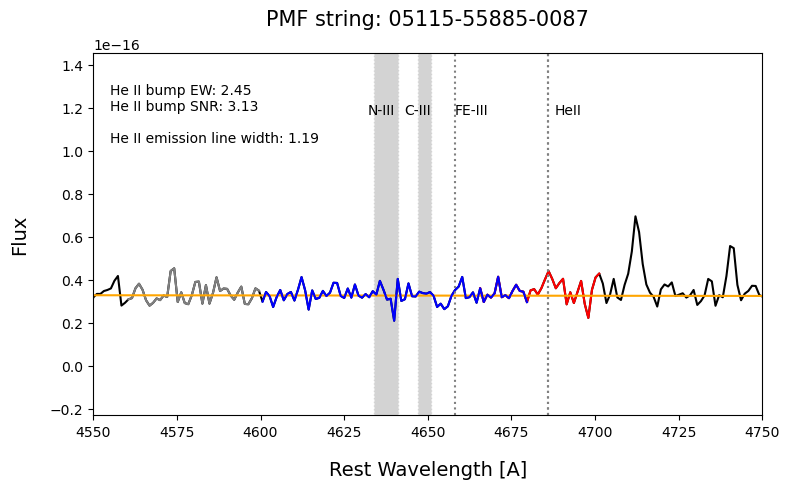

111


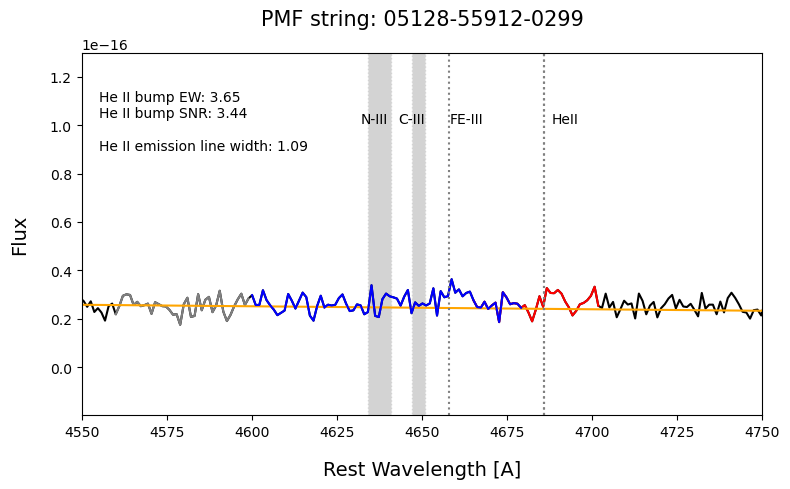

112


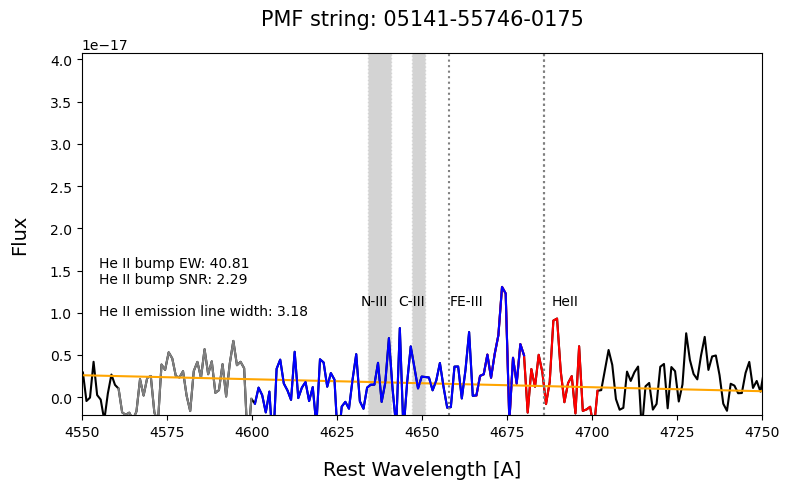

113


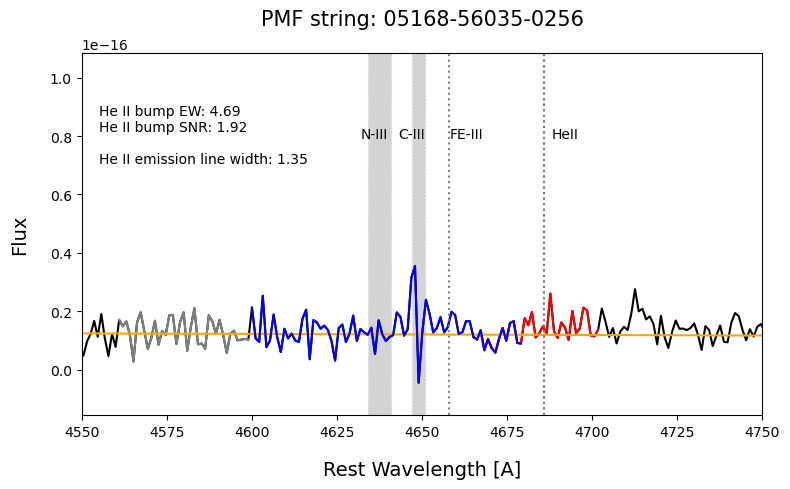

114


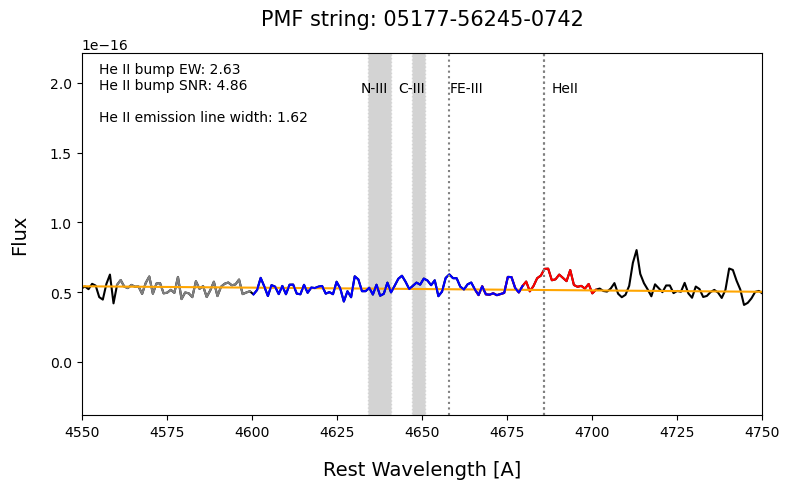

115


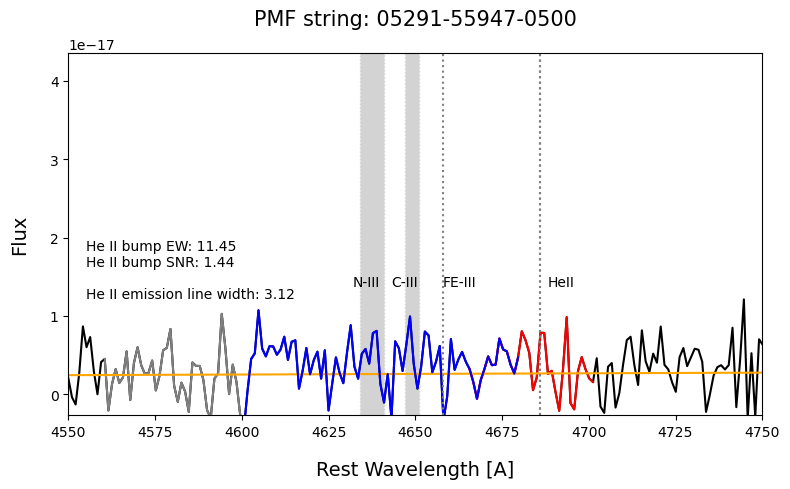

116


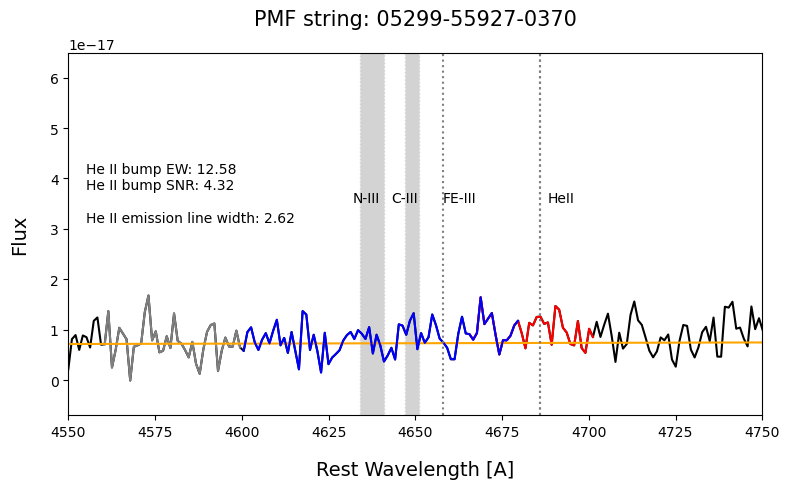

117


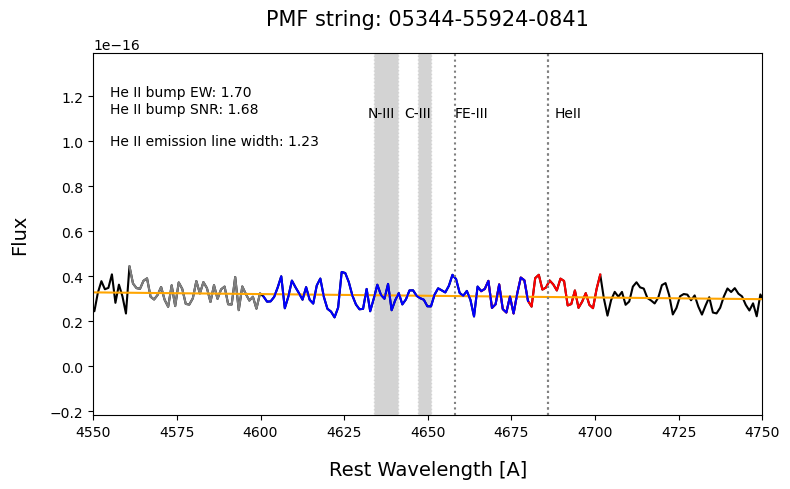

118


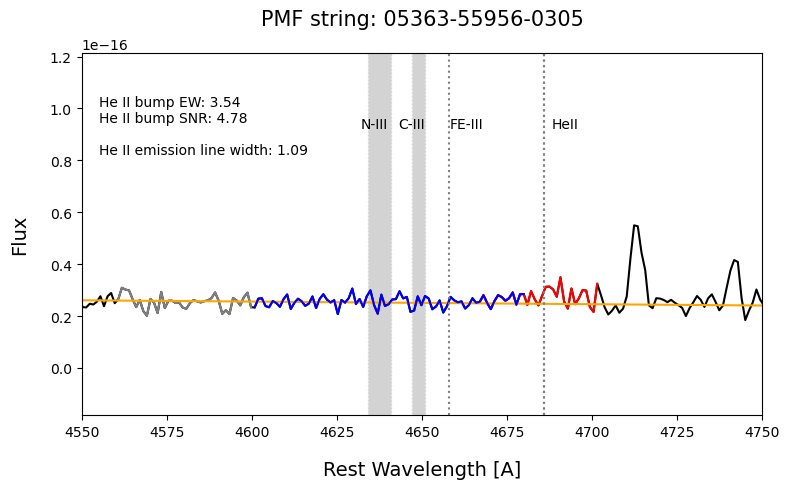

119


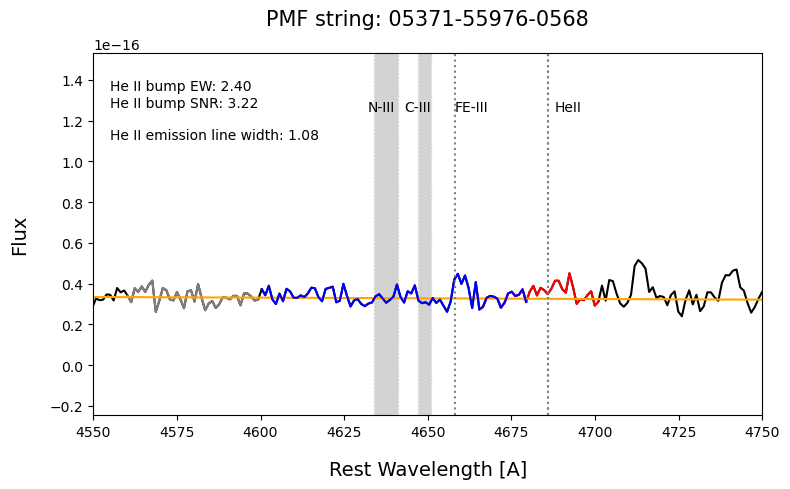

120


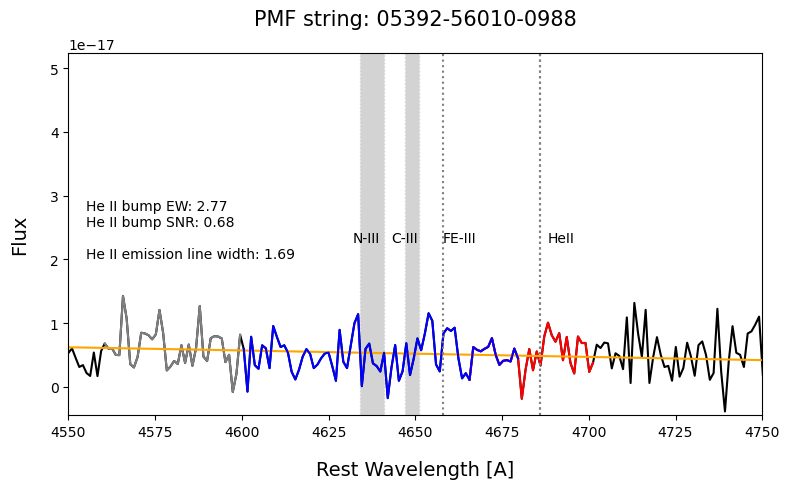

121


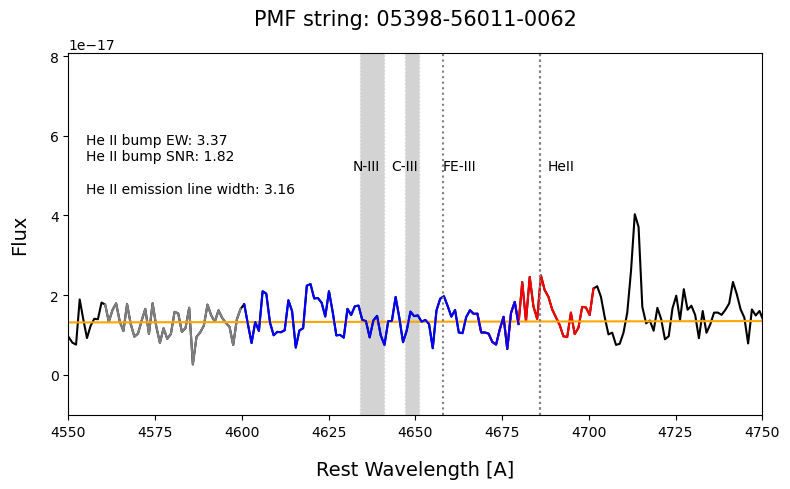

122


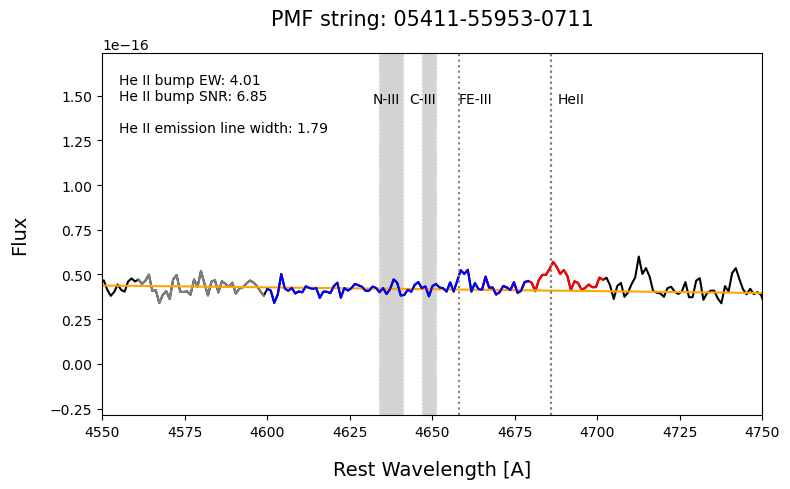

123


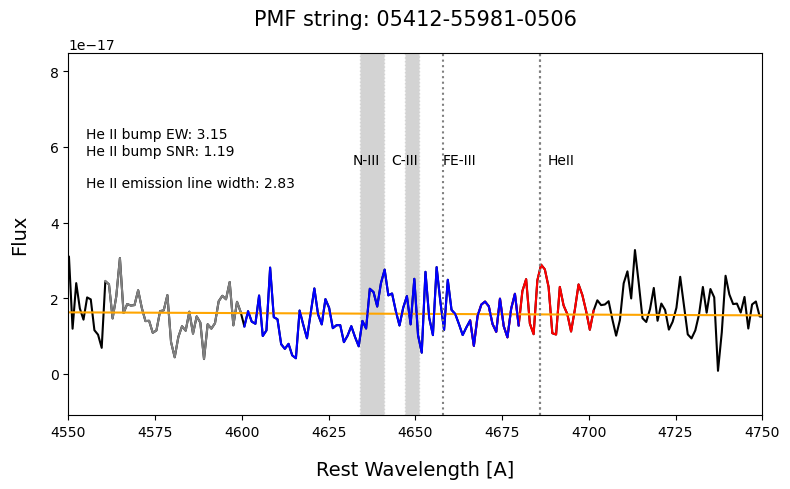

124


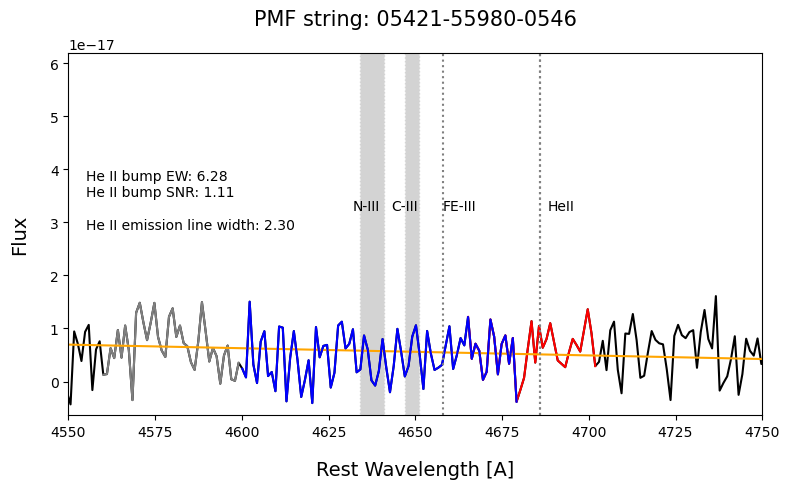

125


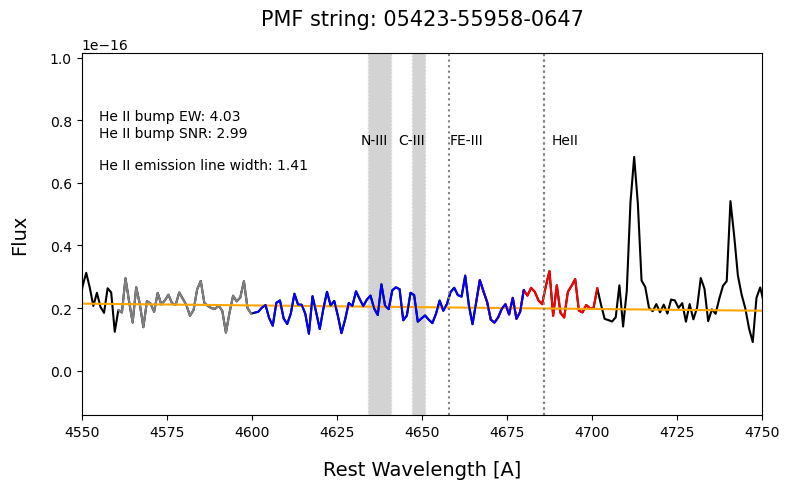

126


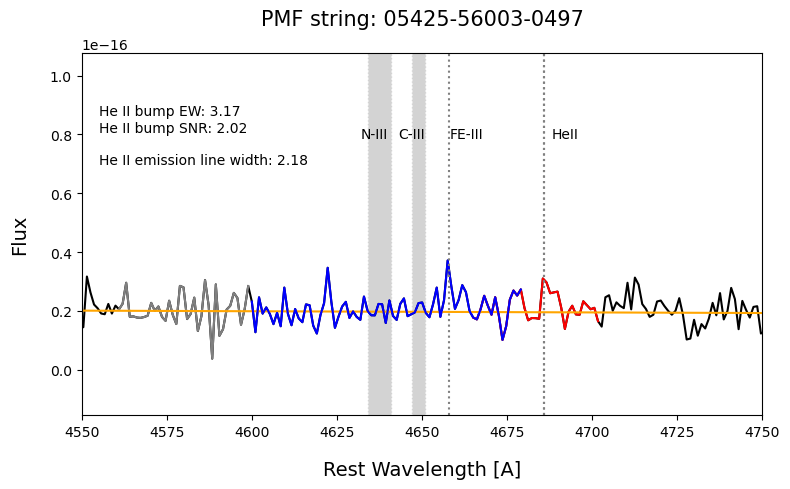

127


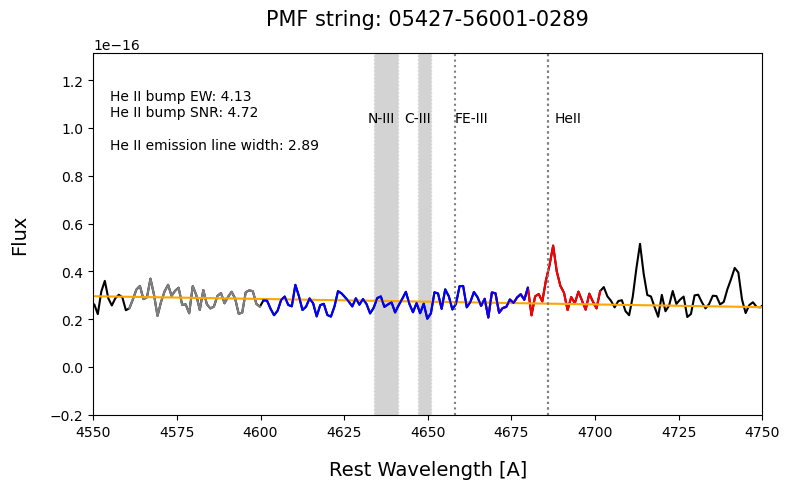

128


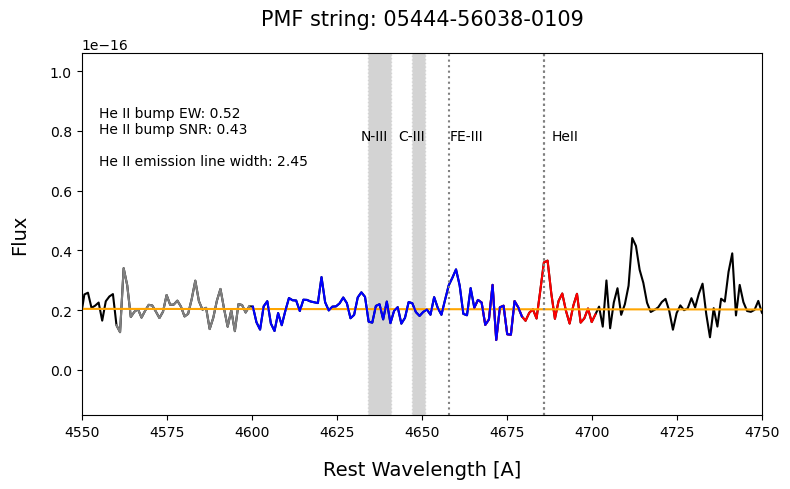

129


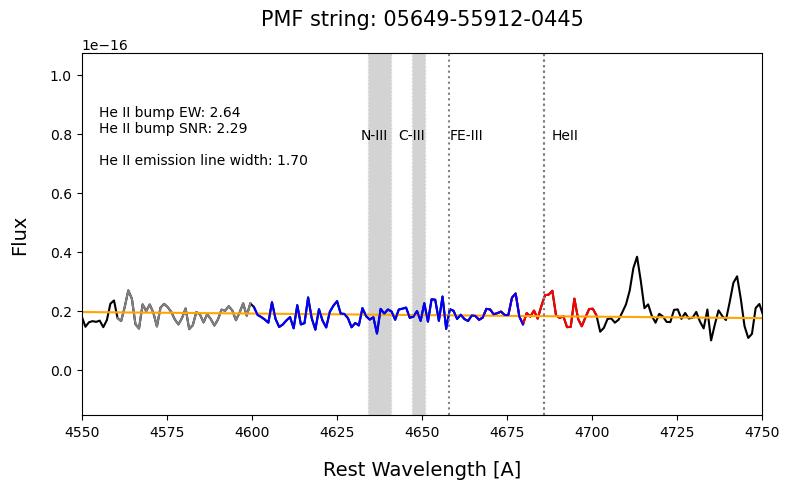

success


In [54]:
# # #~~~~~~~~~~~~~~~~~~~~~~~~~ Plotting Spectra to determine threshold of Wolf-Rayet EW ~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# kay = [0]
# k = np.array(kay)
# k = np.arange(0, len(initial_VMS_eBOSS), 1) 
k = np.arange(110, 130, 1)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
for i in k:
    print(i)
    x = rest_frame_wavelengths_2[i]
    y = rest_frame_flux_densities_2[i]

    #~~~~~~~ Complicated Finding Median Stuff ~~~~~~~~~~~~~~~~~
    max_flux_median = np.max([right_median[i], left_median[i]])
    min_flux_median = np.min([right_median[i], left_median[i]])
    
    if max_flux_median == right_median[i]:
        max_wave_med = right_median_wav[i]
        min_wave_med = left_median_wav[i]
    elif max_flux_median == left_median[i]: ##### learned elif = else if ######
        max_wave_med = left_median_wav[i]
        min_wave_med = right_median_wav[i]
    else: 
        print('failed result:')
        
    ########## New Method of finding base equation ###########
    y_points = np.array([max_flux_median, min_flux_median])
    x_points = np.array([max_wave_med, min_wave_med])
    
    coefficients = np.polyfit(x_points, y_points, 1)
    linear_func = np.poly1d(coefficients)

    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Calculating equivalent wdith of HE II bump ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    x = rest_frame_wavelengths_2[i]
    y = rest_frame_flux_densities_2[i]

    ### Measuring difference between bump flux and baseline equation flux 
    # WolfRayet_bump = outside_bump[i] & (~HeII_bump[i])
    # print(np.shape(WolfRayet_bump))

    bump_wav = rest_frame_wavelengths_2[i][WolfRayet_bump[i]]
    bump_flux = rest_frame_flux_densities_2[i][WolfRayet_bump[i]]
    baseline_flux = linear_func(x)[WolfRayet_bump[i]]
    delta_bump_flux = bump_flux - baseline_flux
    norm_delta_flux = delta_bump_flux / baseline_flux
    
    ##### Calculating Equivalent Width
    EW = np.trapezoid(norm_delta_flux, bump_wav)      

    ############ Creating axes #################
    highlighted = right_flat[i] | left_flat[i] # "Flat" continuum portions
    
    yblue = rest_frame_flux_densities_2[i].copy()
    yblue[~highlighted] = np.nan
    
    ybump = rest_frame_flux_densities_2[i].copy()
    ybump[~HeII_bump[i]] = np.nan

    out_bump = rest_frame_flux_densities_2[i].copy()
    out_bump[~WolfRayet_bump[i]] = np.nan
    
    yspectra = rest_frame_flux_densities_2[i].copy()
    yspectra[~between[i]] = np.nan

    # baseline = equation.copy()
    baseline = linear_func(x).copy()
    baseline[~between[i]] = np.nan

    # median smoothing 
    median_smooth_flux = median_filter(rest_frame_flux_densities_2[i], size=5, mode='reflect')

    plt.figure(figsize=(8,5))
    plt.title(f'PMF string: {initial_VMS_eBOSS['PMF_STRING'][i]}', fontsize=15, pad=20)

    ############### Plotting ###################
    plt.plot(x, yspectra, color='black')
    plt.plot(x, yblue, color='gray')
    plt.plot(x, ybump, color='red', label = 'He II bump')
    plt.plot(x, baseline, color='orange')
    plt.plot(x, out_bump, color ='blue')
    # plt.scatter(x_points, y_points, color='green')
    # plt.step(x, median_smooth_flux, where='mid', color='red', label='smoothed data')


    median_flux = np.median(rest_frame_flux_densities_2[i])
    lower_y_lim = median_flux * -1
    upper_y_lim = median_flux * 5

    plt.xlim(4550, 4750)

    plt.axvline(4686, color='grey',linestyle='dotted', label='HeII')
    plt.axvline(4861, color='grey',linestyle='dotted', label='H-beta')
    plt.axvline(4686, color='grey',linestyle='dotted', label='HeII')
    plt.text(4686+2, upper_y_lim + (upper_y_lim/85), 'HeII')
    # plt.axvline(4861, color='grey',linestyle='dotted', label='H-beta')
    # plt.text(4861, upper_y_lim + (upper_y_lim/85), 'H-beta')
    plt.axvspan(4634, 4641, color='lightgrey',linestyle='dotted', label='N-III')
    plt.text(4632, upper_y_lim + (upper_y_lim/85), 'N-III')
    plt.axvline(4658, color='grey',linestyle='dotted', label='FE-III')
    plt.text(4658, upper_y_lim + (upper_y_lim/85), 'FE-III')
    plt.axvspan(4647, 4651, color='lightgrey',linestyle='dotted', label='C-III')
    plt.text(4643, upper_y_lim + (upper_y_lim/85), 'C-III')

    # plt.text(4555, (0.9 * upper_y_lim), f'He II bump EW: {initial_VMS_eBOSS['HeII_4686_BUMP_EW'][i]:.2f}\nHe II bump SNR: {initial_VMS_eBOSS['HeII_4686_BUMP_EW_SNR'][i]:.2f}\n\nBlue bump EW: {wolf_rayet_bump_EWs[i]:.2f}')
    plt.text(4555, (0.9 * upper_y_lim), f'He II bump EW: {HeII4686_bump_EWs[i]:.2f}\nHe II bump SNR: {HeII4686_bump_EW_SNR[i]:.2f}\n\nHe II emission line width: {initial_VMS_eBOSS['HEII_4686_EW'][i]:.2f}')
    plt.ylim(lower_y_lim, (upper_y_lim + 3e-17))
    plt.ylim(lower_y_lim, (upper_y_lim + 3e-17))

    plt.xlabel('Rest Wavelength [A]', fontsize=14, labelpad=15)
    plt.ylabel('Flux', fontsize=14, labelpad=15)

    plt.tight_layout() 
    plt.show()

print('success')

In [ ]:
p = []
m = []
f = []
wolf_rayet_gals = [p, m, f]

In [ ]:
# p = [11288, 05411, 03694]
# m = [58401, 55953, 55209]
# f = [0544, 0711, 0754]

p = [11288, 5411, 3694]
m = [58401, 55953, 55209]
f = [544, 711, 754]
VMS_pot = [p, m, f]